## Bibliotecas/Base de dados

In [1]:
import pandas as pd
import pathlib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import train_test_split

In [2]:
meses = {'jan':1, 'fev':2, 'mar':3, 'abr':4, 'mai':5, 'jun':6, 'jul':7, 'ago':8, 'set':9, 'out':10, 'nov':11, 'dez':12}

caminho_base_dados = pathlib.Path('dataset')

lista_dataframes = []

for arquivo in caminho_base_dados.iterdir():
    nome_mes = arquivo.name[:3]
    mes = meses[nome_mes]

    ano = arquivo.name[-8:]
    ano = int(ano.replace('.csv', ''))

    df = pd.read_csv(caminho_base_dados / arquivo.name,low_memory=False)
    df['ano'] = ano
    df['mes'] = mes
    lista_dataframes.append(df)

base_airbnb = pd.concat(lista_dataframes, ignore_index=True)
display(base_airbnb)

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,number_of_reviews_ltm,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,14063,https://www.airbnb.com/rooms/14063,20180414160018,2018-04-14,Living in a Postcard,"Besides the most iconic's view, our apartment ...",NaN,"Besides the most iconic's view, our apartment ...",none,Best and favorite neighborhood of Rio. Perfect...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17878,https://www.airbnb.com/rooms/17878,20180414160018,2018-04-14,Very Nice 2Br - Copacabana - WiFi,Please note that special rates apply for New Y...,- large balcony which looks out on pedestrian ...,Please note that special rates apply for New Y...,none,This is the best spot in Rio. Everything happe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24480,https://www.airbnb.com/rooms/24480,20180414160018,2018-04-14,Nice and cozy near Ipanema Beach,My studio is located in the best of Ipanema. ...,The studio is located at Vinicius de Moraes St...,My studio is located in the best of Ipanema. ...,none,"The beach, the lagoon, Ipanema is a great loca...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25026,https://www.airbnb.com/rooms/25026,20180414160018,2018-04-14,Beautiful Modern Decorated Studio in Copa,"Our apartment is a little gem, everyone loves ...",This newly renovated studio (last renovations ...,"Our apartment is a little gem, everyone loves ...",none,Copacabana is a lively neighborhood and the ap...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31560,https://www.airbnb.com/rooms/31560,20180414160018,2018-04-14,NICE & COZY 1BDR - IPANEMA BEACH,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,none,Die Nachbarschaft von Ipanema ist super lebend...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,38844730,https://www.airbnb.com/rooms/38844730,20190923212307,2019-09-24,TRANSAMERICA BARRA DA TIJUCA R IV,"Em estilo contemporâneo, o Transamerica Prime ...",NaN,"Em estilo contemporâneo, o Transamerica Prime ...",none,NaN,...,1.0,1.0,1125.0,1125.0,1.0,1125.0,0.0,15.0,0.0,0.0
902206,38846408,https://www.airbnb.com/rooms/38846408,20190923212307,2019-09-24,Alugo para o Rock in Rio,"Confortável apartamento, 2 quartos , sendo 1 s...",O apartamento estará com mobília completa disp...,"Confortável apartamento, 2 quartos , sendo 1 s...",none,"Muito próximo ao Parque Olímpico, local do eve...",...,2.0,2.0,1125.0,1125.0,2.0,1125.0,0.0,1.0,0.0,0.0
902207,38846703,https://www.airbnb.com/rooms/38846703,20190923212307,2019-09-24,Apt COMPLETO em COPACABANA c/TOTAL SEGURANÇA,Apartamento quarto e sala COMPLETO para curtas...,Espaço ideal para até 5 pessoas. Cama de casal...,Apartamento quarto e sala COMPLETO para curtas...,none,NaN,...,3.0,3.0,1125.0,1125.0,3.0,1125.0,0.0,23.0,6.0,0.0
902208,38847050,https://www.airbnb.com/rooms/38847050,20190923212307,2019-09-24,Cobertura Cinematografica,Cobertura alto nivel,NaN,Cobertura alto nivel,none,NaN,...,1.0,1.0,1125.0,1125.0,1.0,1125.0,0.0,1.0,0.0,0.0


## Filtrando as colunas que serão utilizadas

In [3]:
colunas = ['host_response_time','host_response_rate','host_is_superhost','host_listings_count','latitude','longitude','property_type','room_type','accommodates','bathrooms','bedrooms','beds','bed_type','amenities','price','security_deposit','cleaning_fee','guests_included','extra_people','minimum_nights','maximum_nights','number_of_reviews','review_scores_rating','review_scores_accuracy','review_scores_cleanliness','review_scores_checkin','review_scores_communication','review_scores_location','review_scores_value','instant_bookable','is_business_travel_ready','cancellation_policy','ano','mes']

base_airbnb = base_airbnb.loc[:, colunas]
display(base_airbnb)

,host_response_time,host_response_rate,host_is_superhost,host_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
0,NaN,NaN,f,1.0,-22.946854,-43.182737,Apartment,Entire home/apt,4,1.0,...,9.0,9.0,9.0,9.0,9.0,f,f,strict_14_with_grace_period,2018,4
1,within an hour,100%,t,2.0,-22.965919,-43.178962,Condominium,Entire home/apt,5,1.0,...,9.0,10.0,10.0,9.0,9.0,t,f,strict,2018,4
2,within an hour,100%,f,1.0,-22.985698,-43.201935,Apartment,Entire home/apt,2,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,2018,4
3,within an hour,100%,f,3.0,-22.977117,-43.190454,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,2018,4
4,within an hour,100%,t,1.0,-22.983024,-43.214270,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,t,f,strict,2018,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,within an hour,93%,f,0.0,-23.003180,-43.342840,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,2019,9
902206,NaN,NaN,f,0.0,-22.966640,-43.393450,Apartment,Entire home/apt,4,2.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,2019,9
902207,within a few hours,74%,f,32.0,-22.962080,-43.175520,Apartment,Entire home/apt,5,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,2019,9
902208,NaN,NaN,f,0.0,-23.003400,-43.341820,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,2019,9


## Tratamento dos valores faltantes (NaN)
- Visualizando os dados, percebi que existem algumas colunas com muitos dados faltantes, portando foi adicionado um filtro para excluir todas as colunas com mais de 300.000 dados faltantes.
- Para as outras colunas com menos dados faltantes, serão excluidos apenas as linhas vazias (NaN)

In [4]:
for coluna in base_airbnb:
    if base_airbnb[coluna].isnull().sum() > 300000:
        base_airbnb = base_airbnb.drop(coluna, axis=1)
print(base_airbnb.isnull().sum())

host_is_superhost            460
host_listings_count          460
latitude                       0
longitude                      0
property_type                  0
room_type                      0
accommodates                   0
bathrooms                   1724
bedrooms                     850
beds                        2502
bed_type                       0
amenities                      0
price                          0
guests_included                0
extra_people                   0
minimum_nights                 0
maximum_nights                 0
number_of_reviews              0
instant_bookable               0
is_business_travel_ready       0
cancellation_policy            0
ano                            0
mes                            0
dtype: int64


In [5]:
base_airbnb = base_airbnb.dropna()

print(base_airbnb.isnull().sum())

host_is_superhost           0
host_listings_count         0
latitude                    0
longitude                   0
property_type               0
room_type                   0
accommodates                0
bathrooms                   0
bedrooms                    0
beds                        0
bed_type                    0
amenities                   0
price                       0
guests_included             0
extra_people                0
minimum_nights              0
maximum_nights              0
number_of_reviews           0
instant_bookable            0
is_business_travel_ready    0
cancellation_policy         0
ano                         0
mes                         0
dtype: int64


## Tratamento dos tipos de dados de cada coluna

In [6]:
# Identificando o tipo de variável de cada coluna
print(base_airbnb.dtypes)
print('-' * 80)
print(base_airbnb.iloc[0])

host_is_superhost               str
host_listings_count         float64
latitude                    float64
longitude                   float64
property_type                   str
room_type                       str
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                        str
amenities                       str
price                           str
guests_included               int64
extra_people                    str
minimum_nights                int64
maximum_nights                int64
number_of_reviews             int64
instant_bookable                str
is_business_travel_ready        str
cancellation_policy             str
ano                           int64
mes                           int64
dtype: object
--------------------------------------------------------------------------------
host_is_superhost                                                           f

In [7]:
base_airbnb['price'] = base_airbnb['price'].astype(str)
base_airbnb['price'] = base_airbnb['price'].str.replace('$', '', regex=False)
base_airbnb['price'] = base_airbnb['price'].str.replace(',', '', regex=False)
base_airbnb['price'] = base_airbnb['price'].astype(np.float32)

base_airbnb['extra_people'] = base_airbnb['extra_people'].astype(str)
base_airbnb['extra_people'] = base_airbnb['extra_people'].str.replace('$', '', regex=False)
base_airbnb['extra_people'] = base_airbnb['extra_people'].str.replace(',', '', regex=False)
base_airbnb['extra_people'] = base_airbnb['extra_people'].astype(np.float32)

print(base_airbnb.dtypes)

host_is_superhost               str
host_listings_count         float64
latitude                    float64
longitude                   float64
property_type                   str
room_type                       str
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                        str
amenities                       str
price                       float32
guests_included               int64
extra_people                float32
minimum_nights                int64
maximum_nights                int64
number_of_reviews             int64
instant_bookable                str
is_business_travel_ready        str
cancellation_policy             str
ano                           int64
mes                           int64
dtype: object


## Analisando as correlações/ Excluindo Outliers

<Axes: >

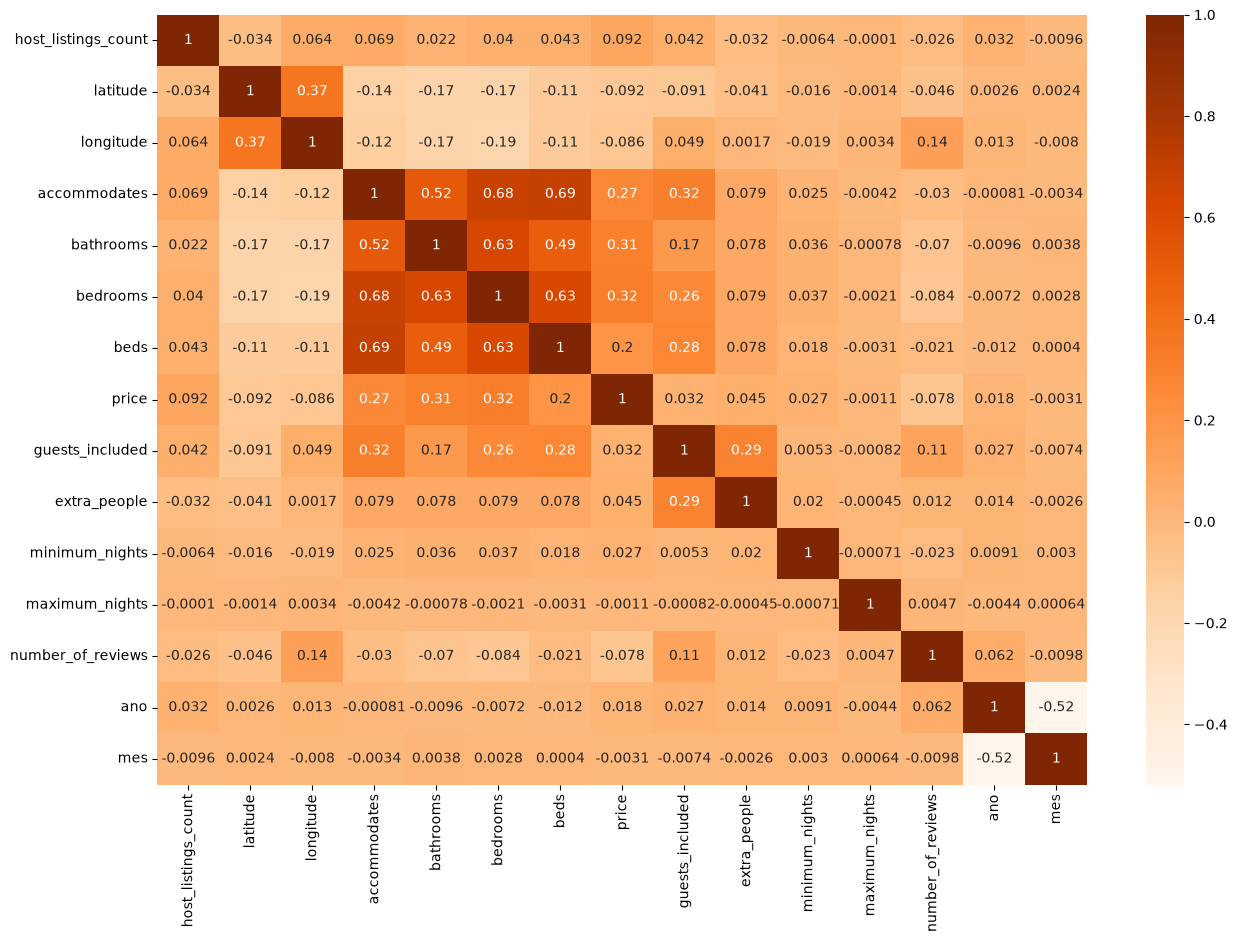

In [8]:
plt.figure(figsize=(15, 10))
sns.heatmap(base_airbnb.corr(numeric_only=True), annot=True, cmap='Oranges')


In [9]:
def limites(coluna):
    q1 = coluna.quantile(0.25)
    q3 = coluna.quantile(0.75)
    amplitude = q3 - q1
    return q1 - (1.5 * amplitude), q3 + (1.5 * amplitude)

def excluir_outlier(df, nome_coluna):
    quantidade_linhas = df.shape[0]
    limite_inferior, limite_superior = limites(df[nome_coluna])
    df = df.loc[(df[nome_coluna] >= limite_inferior) & (df[nome_coluna] <= limite_superior), :]
    linhas_excluidas = quantidade_linhas - df.shape[0]
    return df, linhas_excluidas


In [10]:
def diagrama_caixa(coluna):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(15, 5)
    sns.boxplot(x=coluna, ax=ax1)
    ax2.set_xlim(limites(coluna))
    sns.boxplot(x=coluna, ax=ax2)

def histograma(coluna):
    plt.figure(figsize=(15, 5))
    sns.histplot(coluna)

def grafico_barra(coluna):
    plt.figure(figsize=(15, 5))
    ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts())
    ax.set_xlim(limites(coluna))


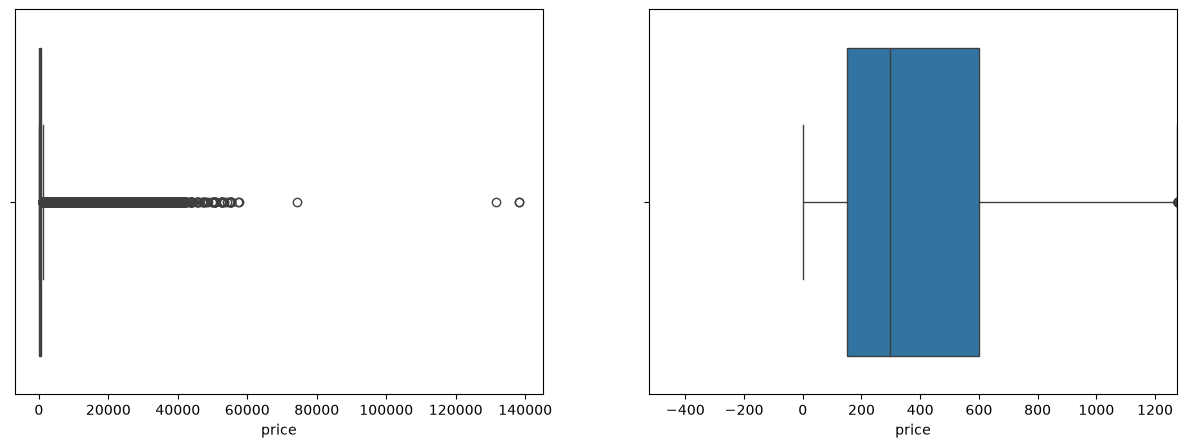

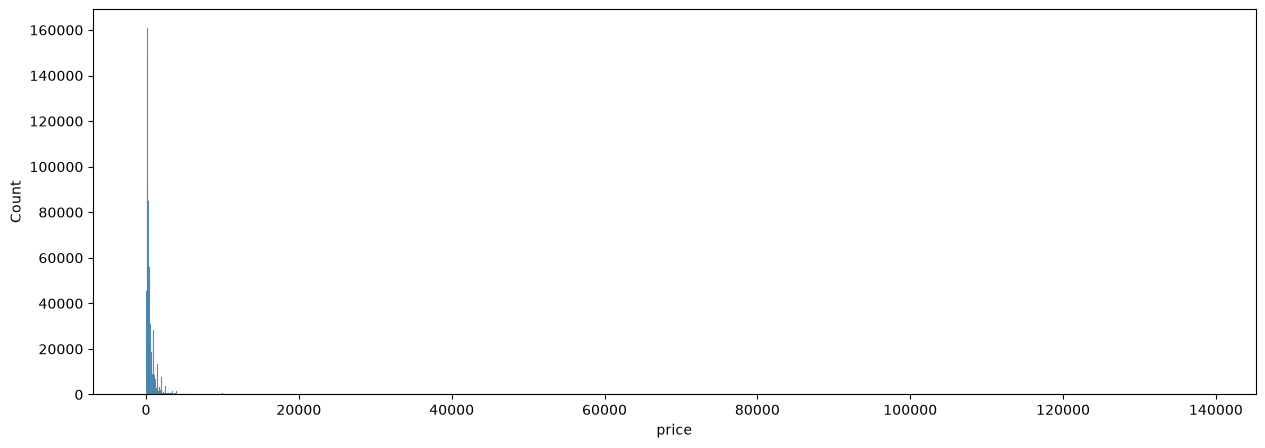

In [11]:
diagrama_caixa(base_airbnb['price'])
histograma(base_airbnb['price'])

Como o objetivo desse projeto é construir um modelo para análise de imóveis comuns (com um preço que varia entre 0 até próximo de 1300 reais), estarei excluindo do resultado aqueles imóveis que são outliers.

In [12]:
base_airbnb, linhas_excluidas = excluir_outlier(base_airbnb, 'price')
print(f'{linhas_excluidas} linhas removidas')

87282 linhas removidas


## Tratamento de Colunas de Valores Numéricos

## Coluna price

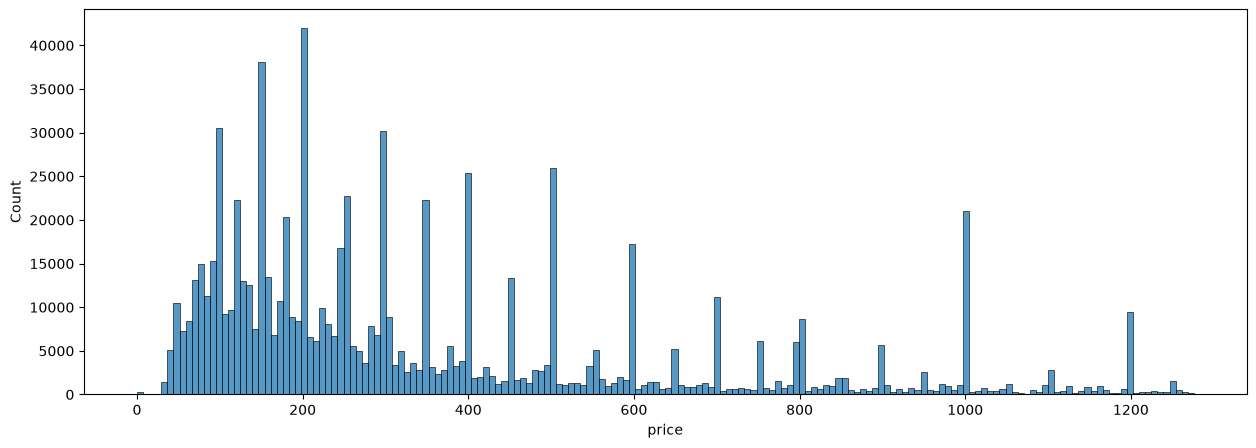

In [13]:
histograma(base_airbnb['price'])

## Coluna extra_people

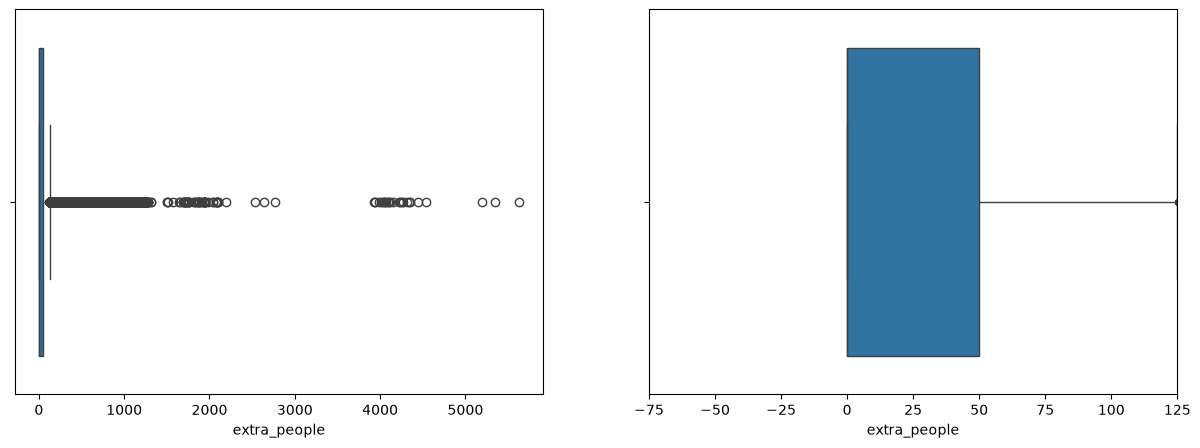

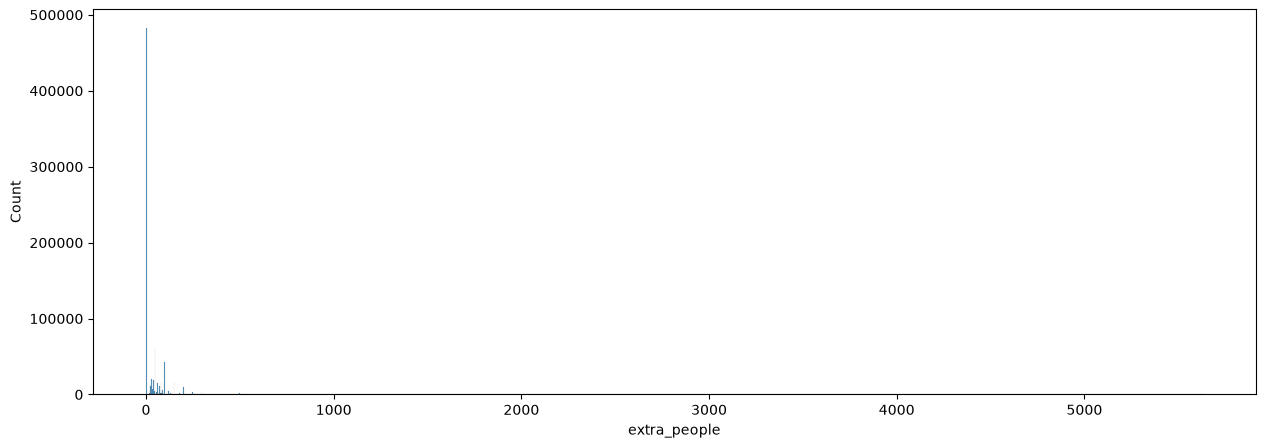

In [14]:
diagrama_caixa(base_airbnb['extra_people'])
histograma(base_airbnb['extra_people'])

In [15]:
base_airbnb, linhas_excluidas = excluir_outlier(base_airbnb, 'extra_people')
print(f'{linhas_excluidas} linhas removidas')

59194 linhas removidas


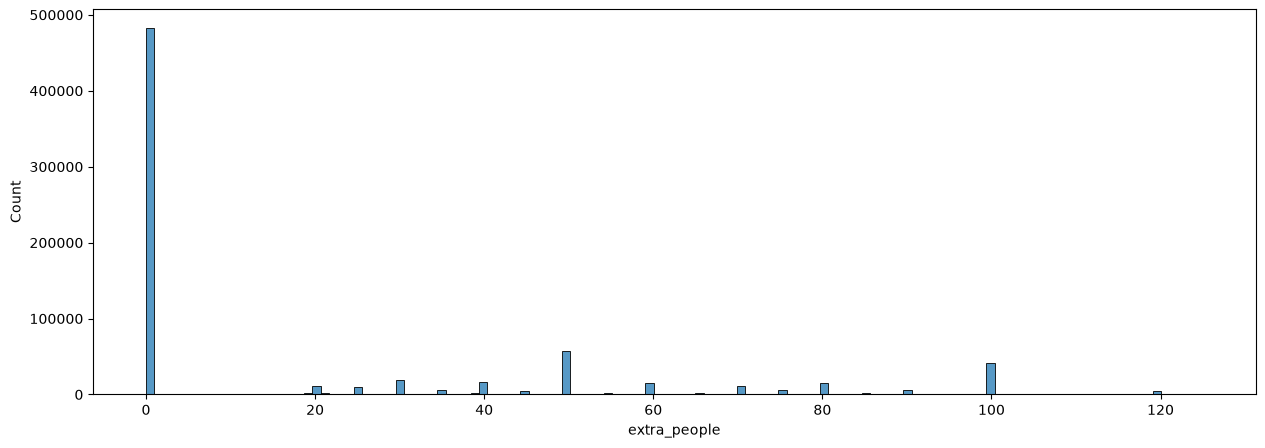

In [16]:
histograma(base_airbnb['extra_people'])

## Coluna host_listings_count

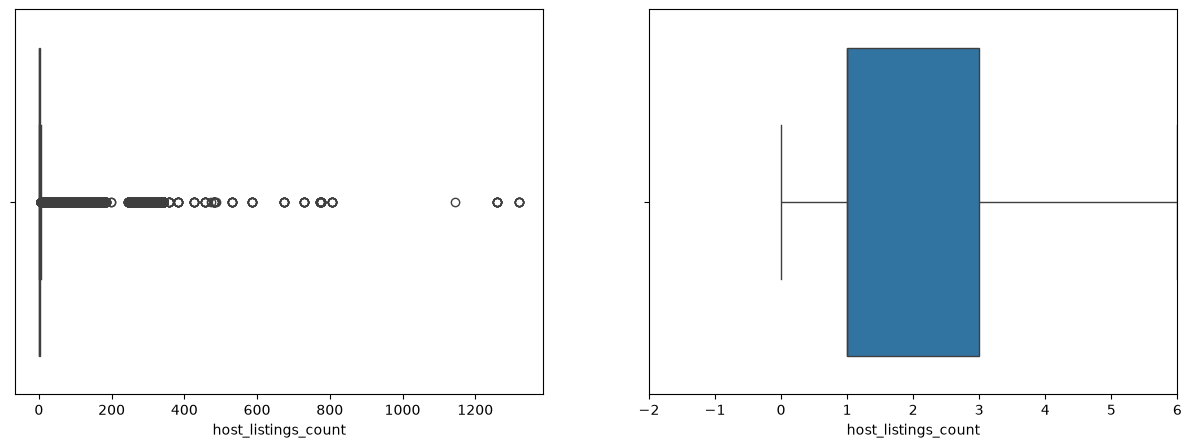

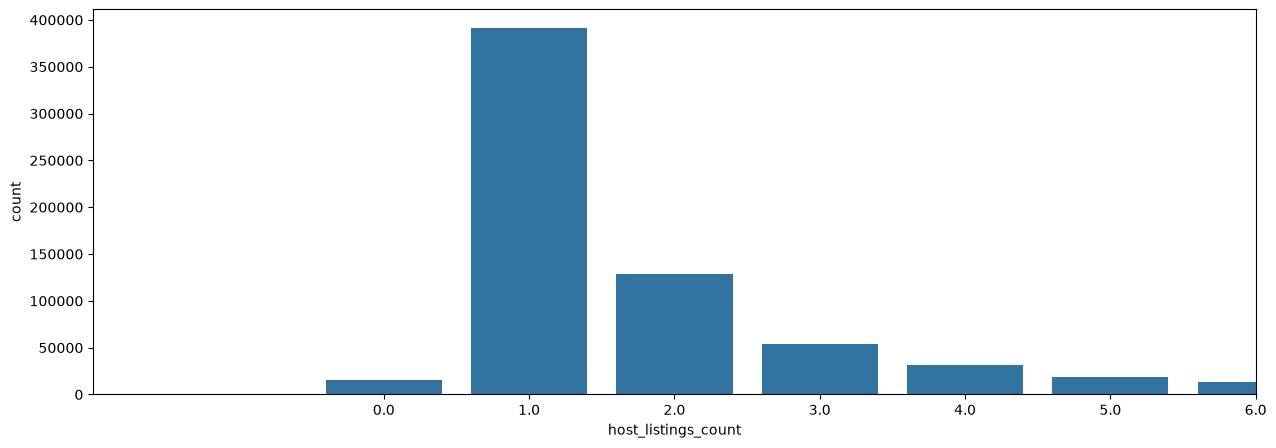

In [17]:
diagrama_caixa(base_airbnb['host_listings_count'])
grafico_barra(base_airbnb['host_listings_count'])

In [18]:
base_airbnb, linhas_excluidas = excluir_outlier(base_airbnb, 'host_listings_count')
print(f'{linhas_excluidas} linhas removidas')

97723 linhas removidas


## Coluna accommodates

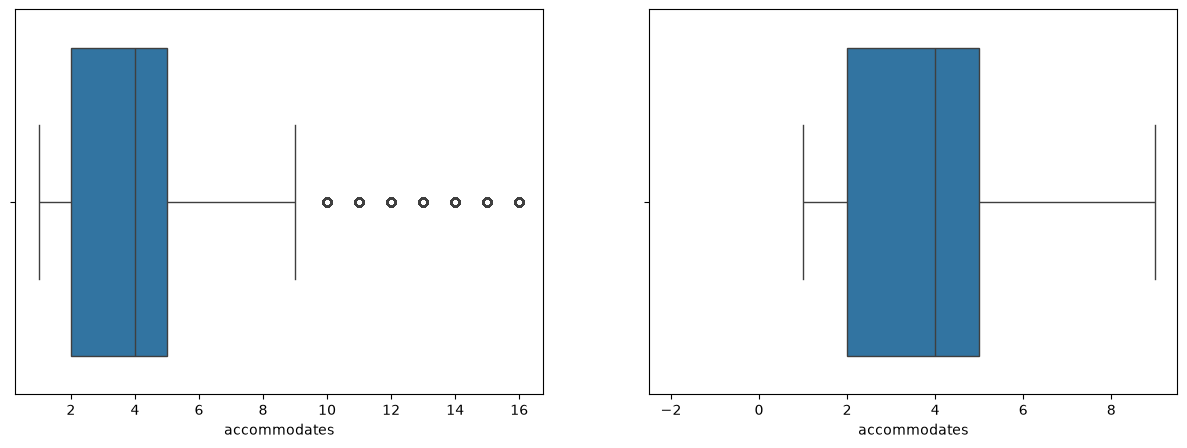

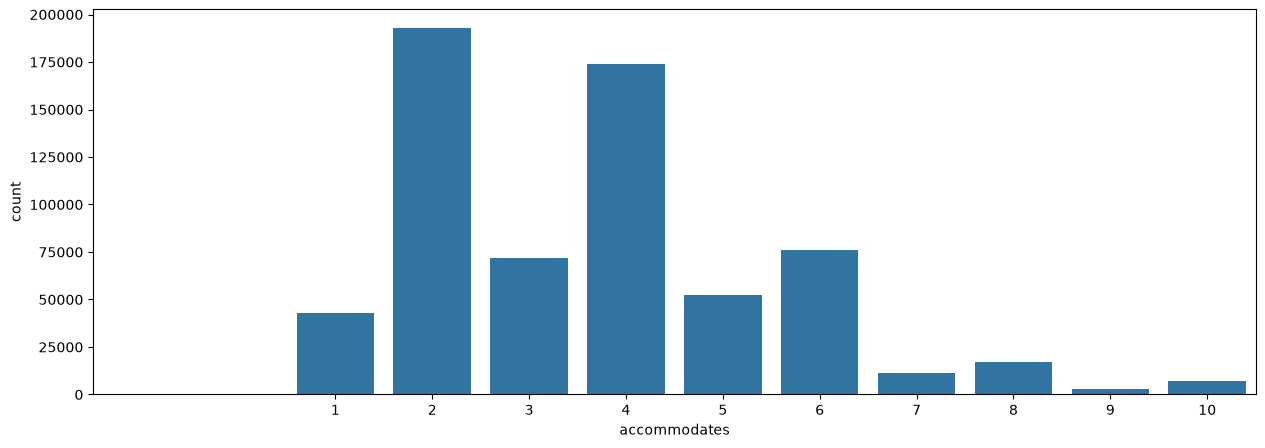

In [19]:
diagrama_caixa(base_airbnb['accommodates'])
grafico_barra(base_airbnb['accommodates'])

In [20]:
base_airbnb, linhas_excluidas = excluir_outlier(base_airbnb, 'accommodates')
print(f'{linhas_excluidas} linhas removidas')

13146 linhas removidas


## Coluna bathrooms

<Axes: xlabel='bathrooms', ylabel='count'>

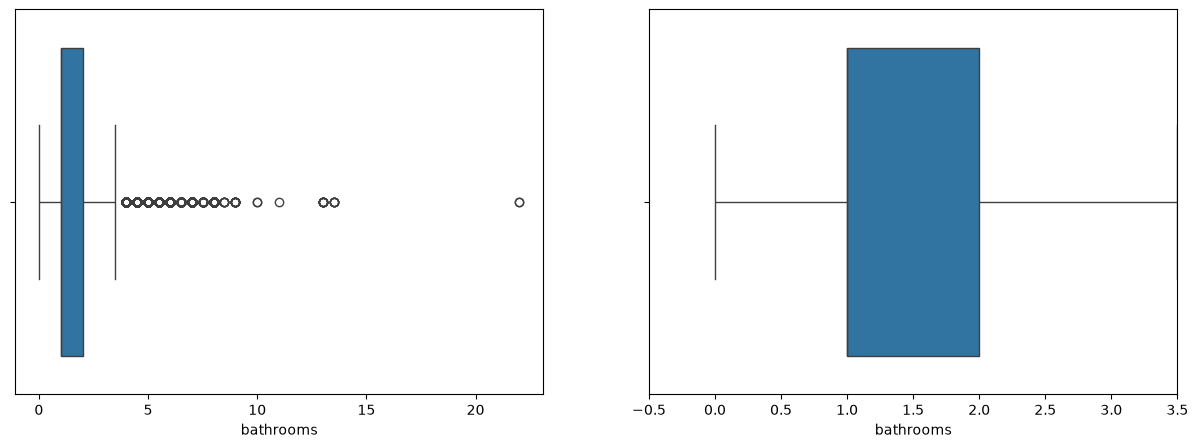

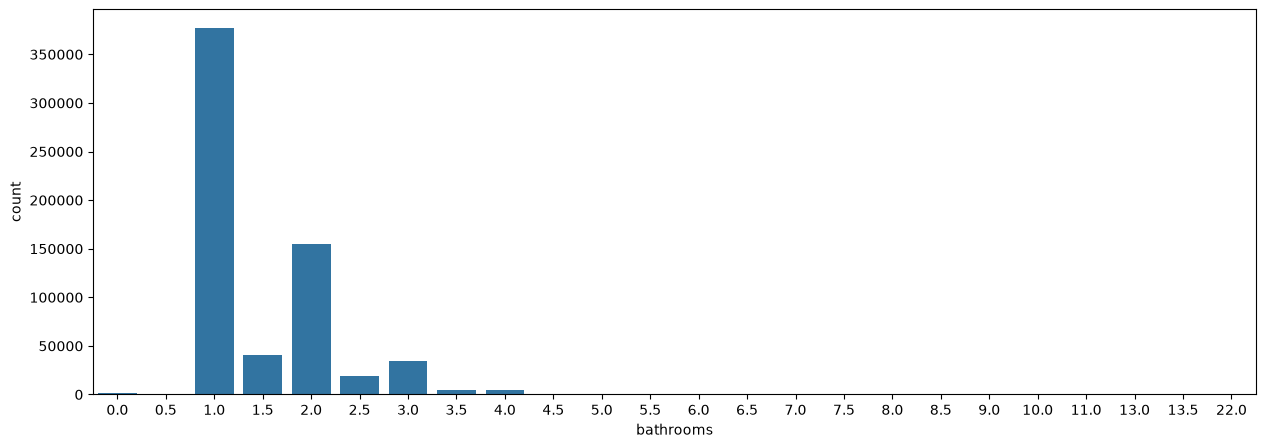

In [21]:
diagrama_caixa(base_airbnb['bathrooms'])
plt.figure(figsize=(15, 5))
sns.barplot(x=base_airbnb['bathrooms'].value_counts().index, y=base_airbnb['bathrooms'].value_counts())

In [22]:
base_airbnb, linhas_excluidas = excluir_outlier(base_airbnb, 'bathrooms')
print(f'{linhas_excluidas} linhas removidas')

6894 linhas removidas


## Coluna beds/bedrooms

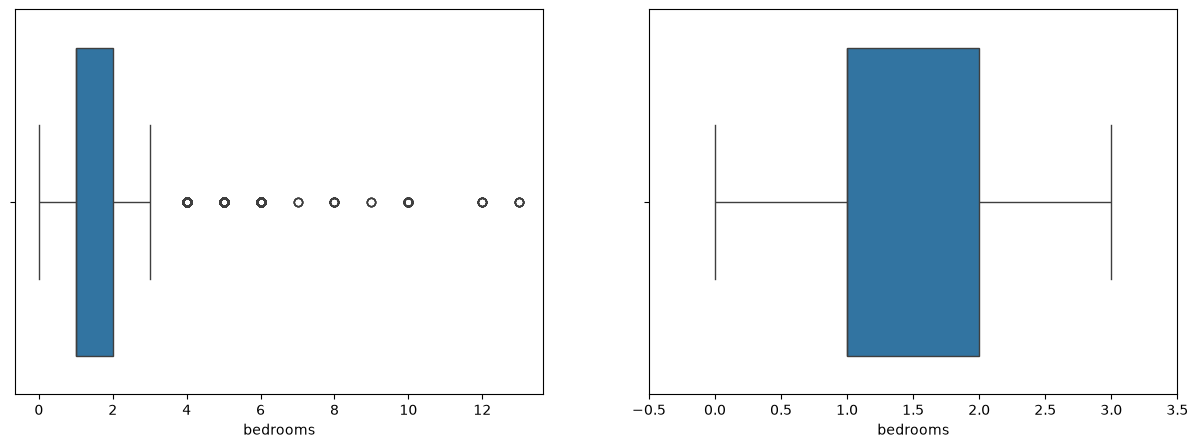

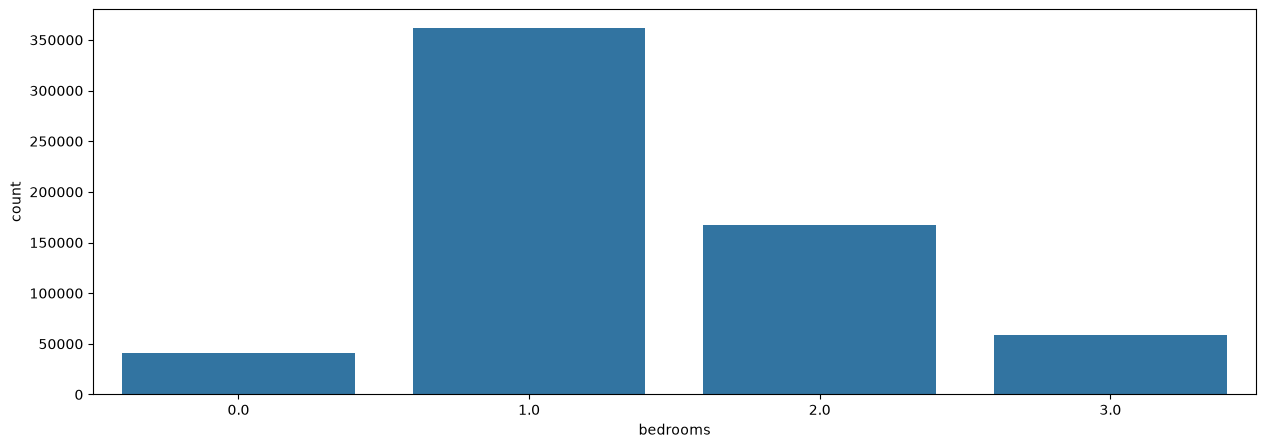

In [23]:
diagrama_caixa(base_airbnb['bedrooms'])
grafico_barra(base_airbnb['bedrooms'])

In [24]:
base_airbnb, linhas_excluidas = excluir_outlier(base_airbnb, 'bedrooms')
print(f'{linhas_excluidas} linhas removidas')

5482 linhas removidas


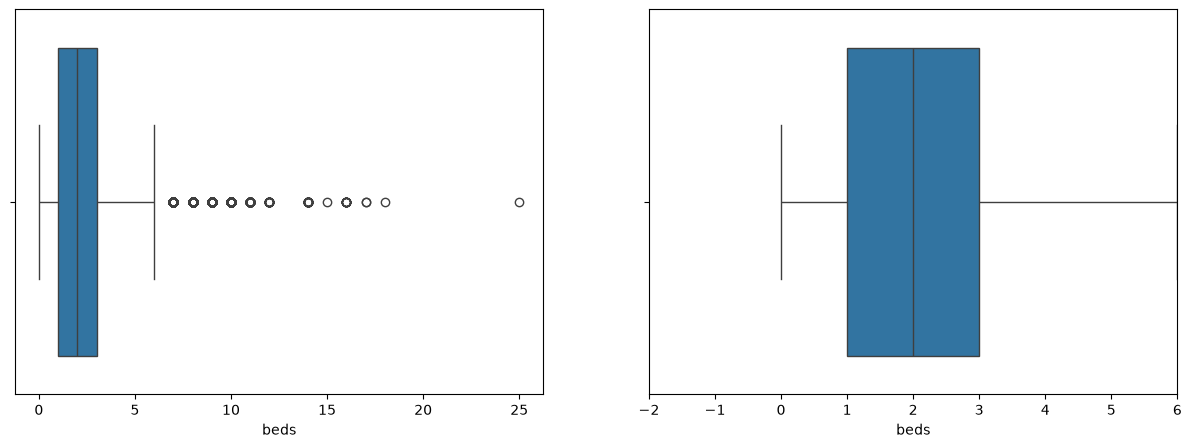

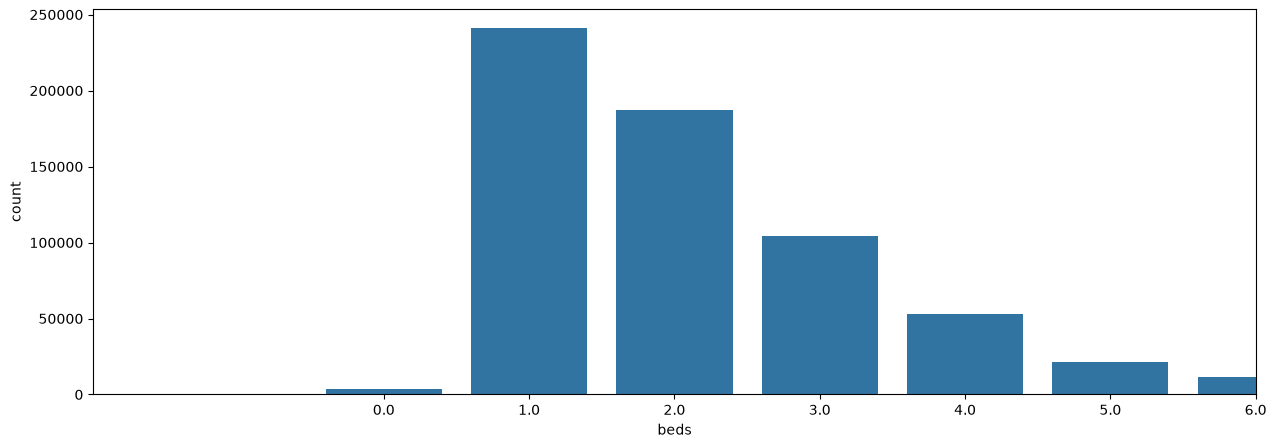

In [25]:
diagrama_caixa(base_airbnb['beds'])
grafico_barra(base_airbnb['beds'])

In [26]:
base_airbnb, linhas_excluidas = excluir_outlier(base_airbnb, 'beds')
print(f'{linhas_excluidas} linhas removidas')

5622 linhas removidas


## Coluna guests_included

<Axes: xlabel='guests_included', ylabel='count'>

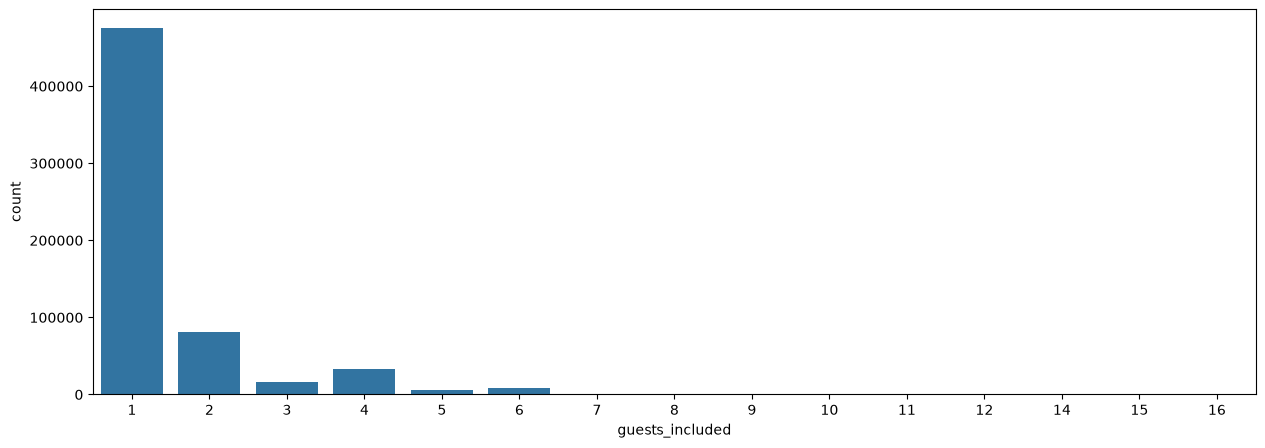

In [27]:
plt.figure(figsize=(15, 5))
sns.barplot(x=base_airbnb['guests_included'].value_counts().index, y=base_airbnb['guests_included'].value_counts())

- Vou remover essa coluna de "guest_included" da análise, pois ao visualizar os dados, me parece que os hosts por padrão utilizam o valor 1. Sendo possível desconsiderar esse dado para nossa análise dos preços.

In [28]:
base_airbnb = base_airbnb.drop('guests_included', axis=1)
base_airbnb.shape

(622366, 22)

## Coluna minimum_nights/maximum_nights

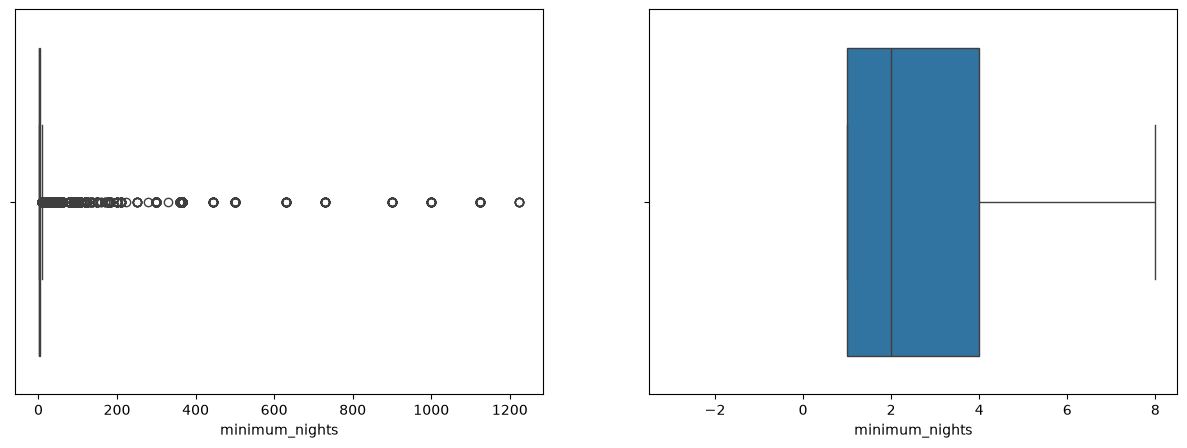

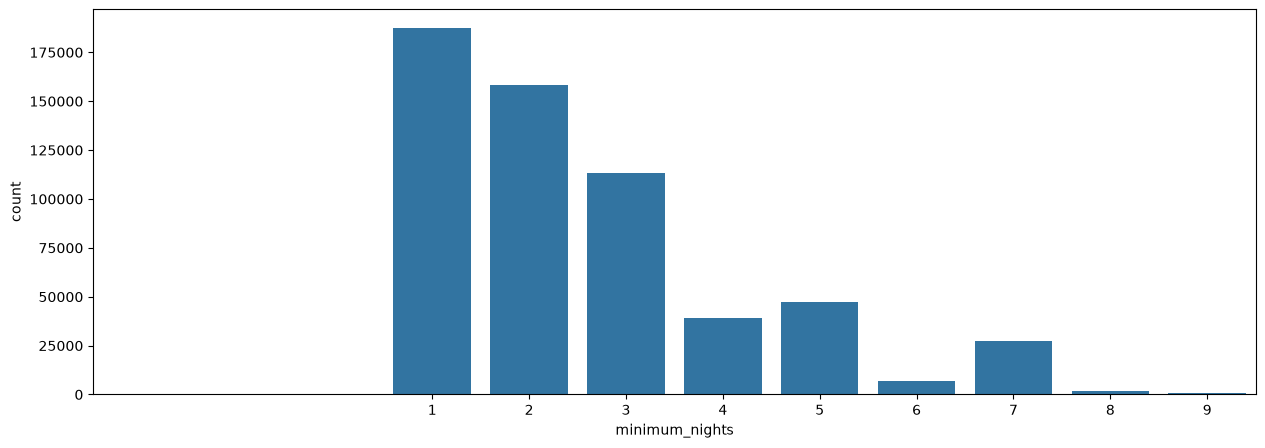

In [29]:
diagrama_caixa(base_airbnb['minimum_nights'])
grafico_barra(base_airbnb['minimum_nights'])

In [30]:
base_airbnb, linhas_excluidas = excluir_outlier(base_airbnb, 'minimum_nights')
print(f'{linhas_excluidas} linhas removidas')

40383 linhas removidas


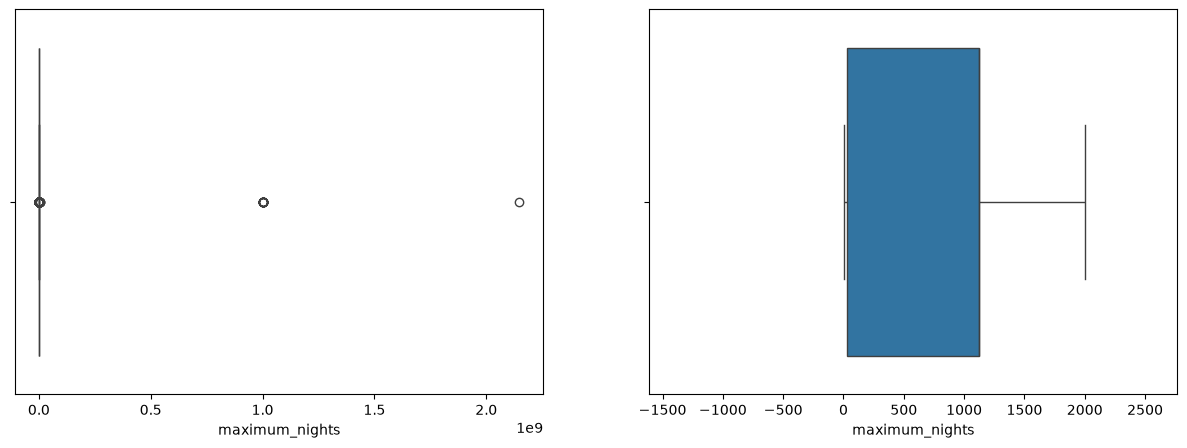

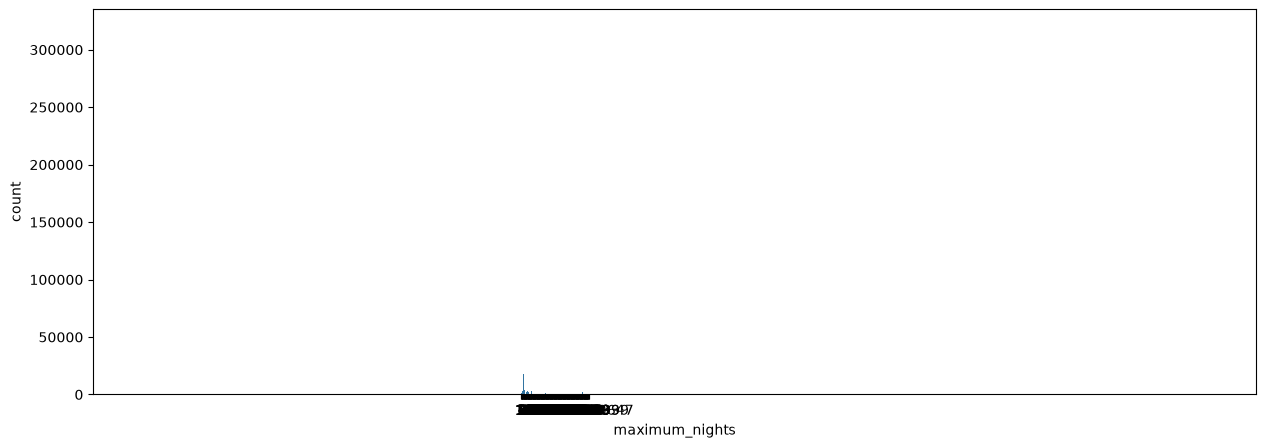

In [31]:
diagrama_caixa(base_airbnb['maximum_nights'])
grafico_barra(base_airbnb['maximum_nights'])

- Vou remover essa coluna de "maximum_nights" da análise.

In [32]:
base_airbnb = base_airbnb.drop('maximum_nights', axis=1)
base_airbnb.shape

(581983, 21)

## Coluna number_of_reviews

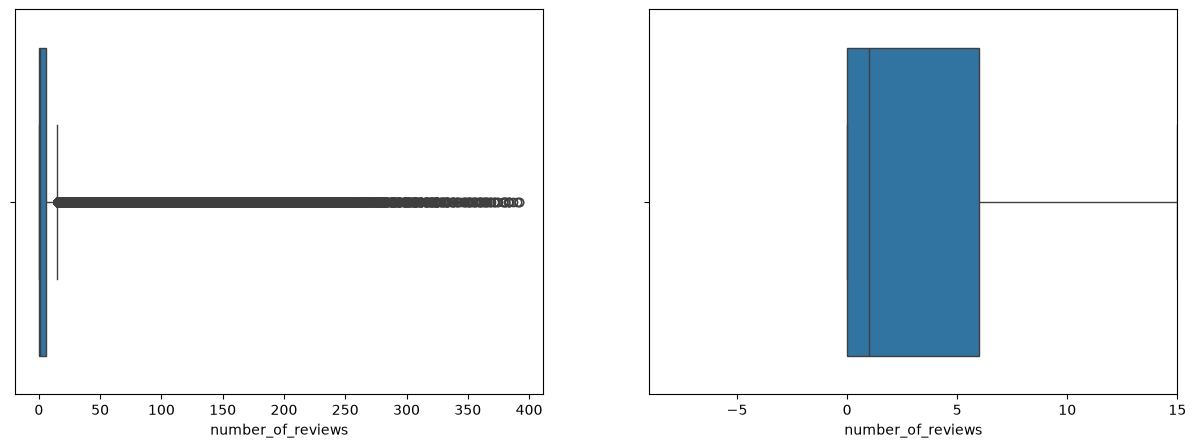

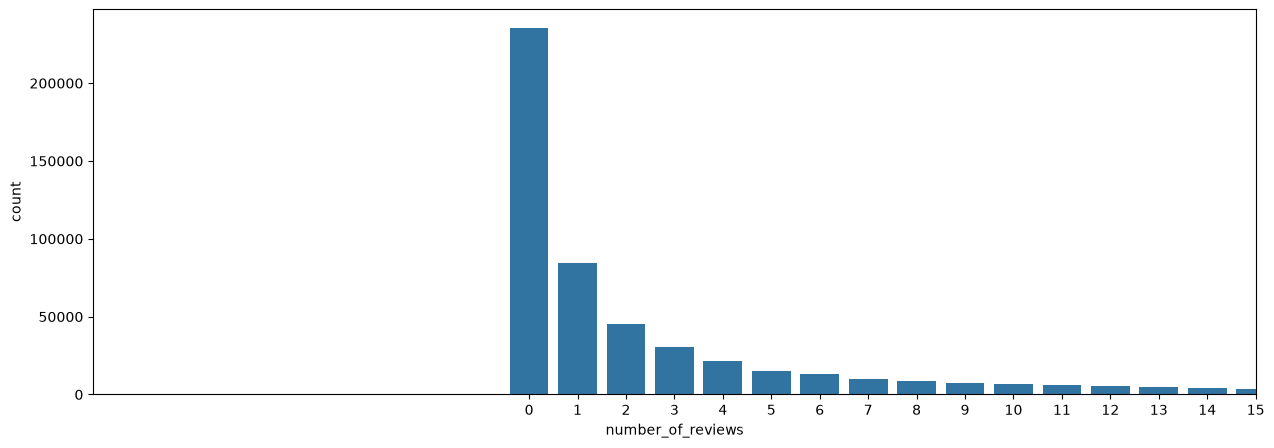

In [33]:
diagrama_caixa(base_airbnb['number_of_reviews'])
grafico_barra(base_airbnb['number_of_reviews'])

- Vou remover essa coluna de "number_of_reviews" da análise.

In [34]:
base_airbnb = base_airbnb.drop('number_of_reviews', axis=1)
base_airbnb.shape

(581983, 20)

## Tratamento de Colunas de Valores Texto

## Coluna property_type

property_type
Apartment                 458354
House                      51387
Condominium                26456
Serviced apartment         12671
Loft                       12352
Guest suite                 3621
Bed and breakfast           3472
Hostel                      2665
Guesthouse                  2155
Other                       1957
Villa                       1294
Townhouse                    969
Aparthotel                   693
Chalet                       481
Earth house                  468
Tiny house                   457
Boutique hotel               447
Hotel                        376
Casa particular (Cuba)       298
Cottage                      230
Bungalow                     207
Dorm                         185
Cabin                        141
Nature lodge                 124
Castle                        80
Treehouse                     76
Island                        54
Boat                          53
Hut                           40
Campsite                     

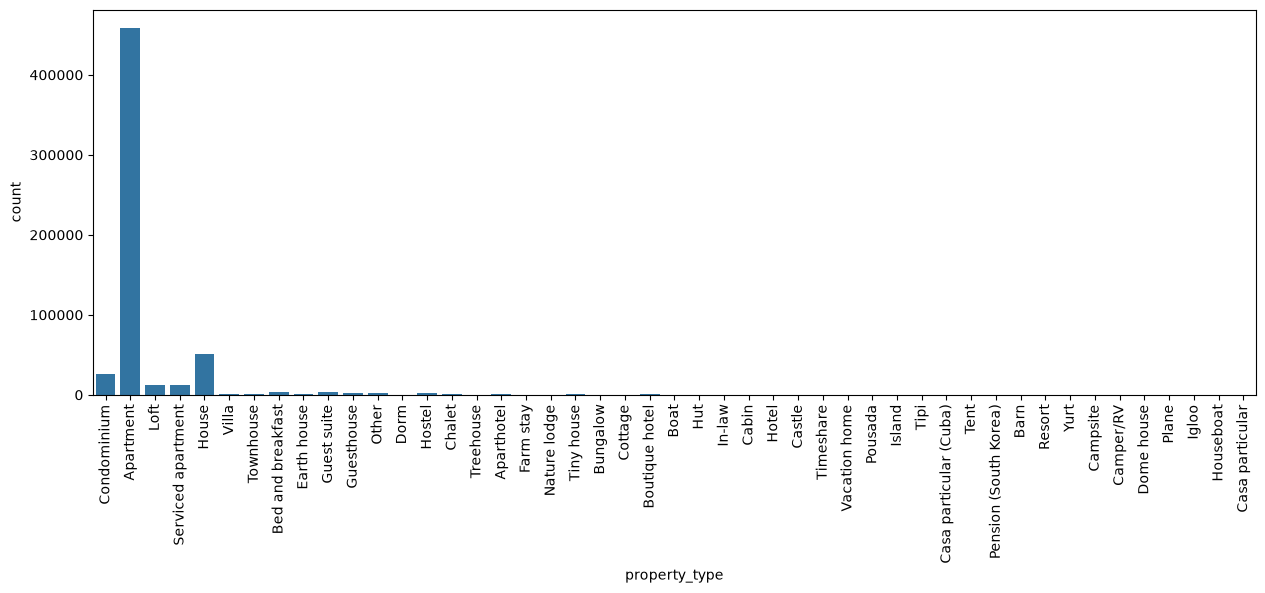

In [35]:
print(base_airbnb['property_type'].value_counts())
plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='property_type', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

['Other', 'Villa', 'Townhouse', 'Aparthotel', 'Chalet', 'Earth house', 'Tiny house', 'Boutique hotel', 'Hotel', 'Casa particular (Cuba)', 'Cottage', 'Bungalow', 'Dorm', 'Cabin', 'Nature lodge', 'Castle', 'Treehouse', 'Island', 'Boat', 'Hut', 'Campsite', 'Resort', 'Camper/RV', 'Yurt', 'Tent', 'Tipi', 'Barn', 'Farm stay', 'Pension (South Korea)', 'Dome house', 'In-law', 'Igloo', 'Vacation home', 'Timeshare', 'Pousada', 'Houseboat', 'Casa particular', 'Plane']
property_type
Apartment             458354
House                  51387
Condominium            26456
Serviced apartment     12671
Loft                   12352
Others                  8850
Guest suite             3621
Bed and breakfast       3472
Hostel                  2665
Guesthouse              2155
Name: count, dtype: int64


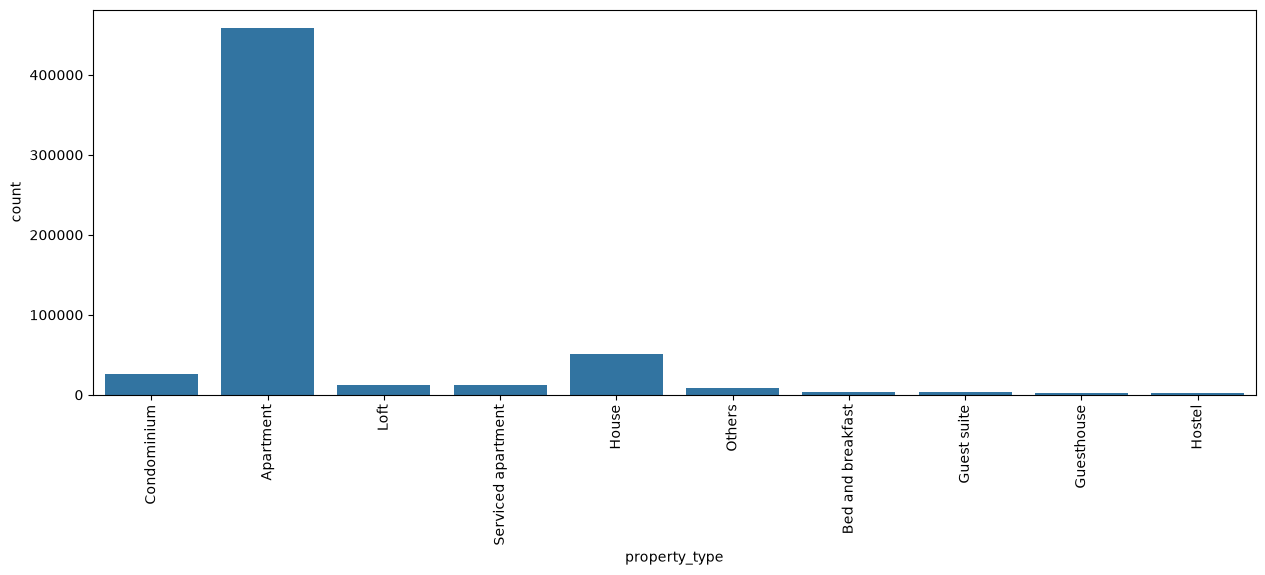

In [36]:
tabela_tipos_imoveis = base_airbnb['property_type'].value_counts()
colunas_agrupadas = []

for tipo in tabela_tipos_imoveis.index:
    if tabela_tipos_imoveis[tipo] < 2000:
        colunas_agrupadas.append(tipo)
print(colunas_agrupadas)

for tipo in colunas_agrupadas:
    base_airbnb.loc[base_airbnb['property_type']==tipo, 'property_type'] = 'Others'

print(base_airbnb['property_type'].value_counts())

plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='property_type', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

## Coluna room_type

room_type
Entire home/apt    372443
Private room       196859
Shared room         11714
Hotel room            967
Name: count, dtype: int64


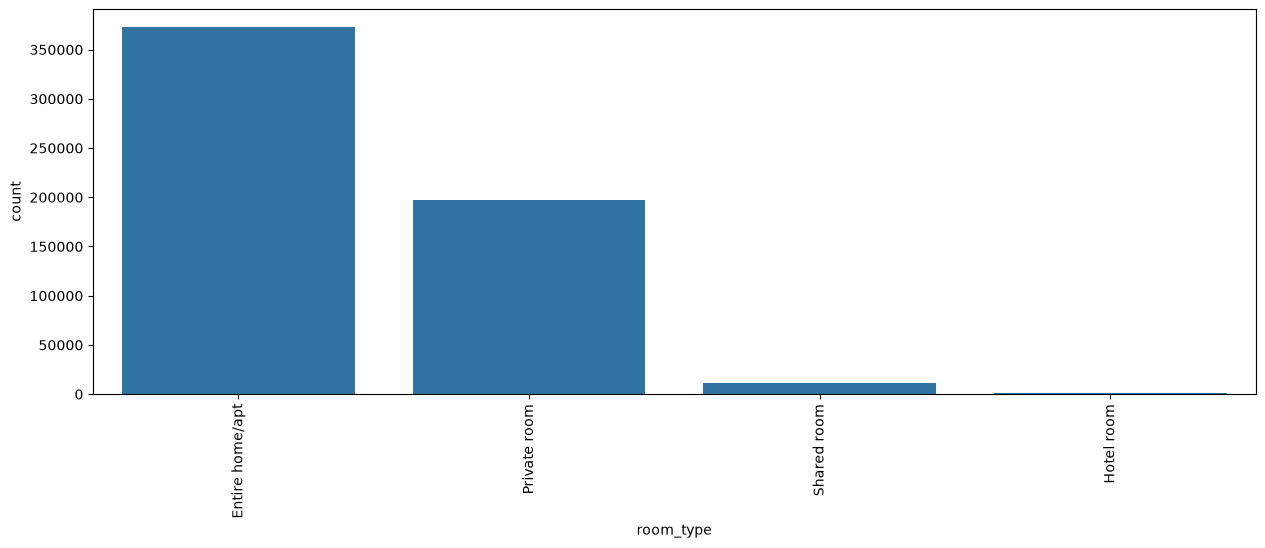

In [37]:
print(base_airbnb['room_type'].value_counts())
plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='room_type', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

## Coluna bed_type

bed_type
Real Bed         570643
Pull-out Sofa      8055
Futon              1634
Airbed             1155
Couch               496
Name: count, dtype: int64


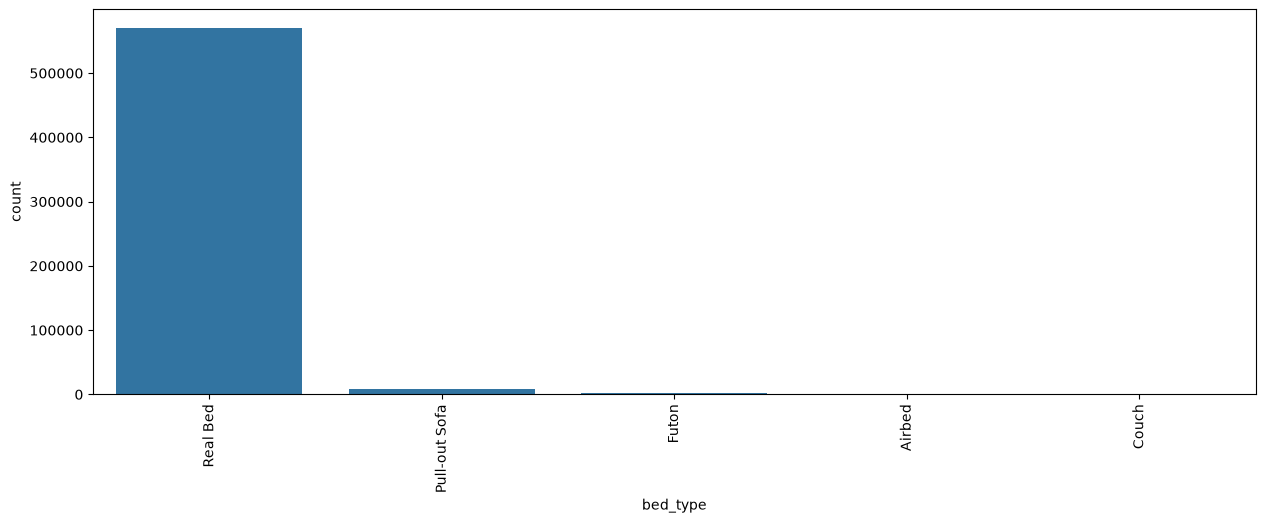

In [38]:
print(base_airbnb['bed_type'].value_counts())
plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='bed_type', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

['Pull-out Sofa', 'Futon', 'Airbed', 'Couch']
bed_type
Real Bed       570643
Others beds     11340
Name: count, dtype: int64


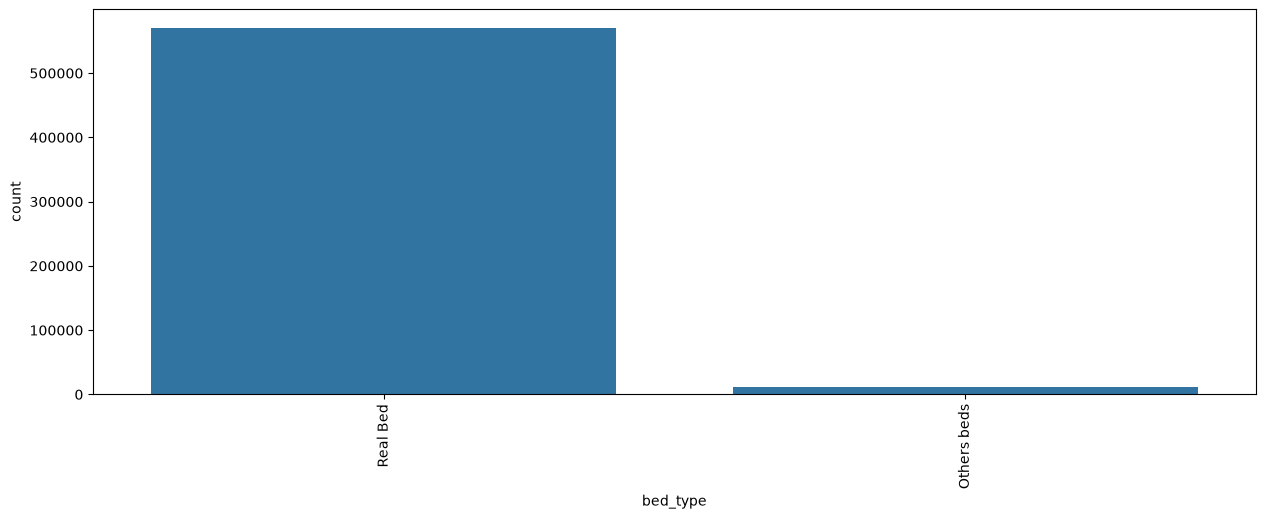

In [39]:
tabela_camas = base_airbnb['bed_type'].value_counts()
colunas_outras_camas = []

for tipo in tabela_camas.index:
    if tabela_camas[tipo] < 9000:
        colunas_outras_camas.append(tipo)
print(colunas_outras_camas)

for tipo in colunas_outras_camas:
    base_airbnb.loc[base_airbnb['bed_type']==tipo, 'bed_type'] = 'Others beds'

print(base_airbnb['bed_type'].value_counts())

plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='bed_type', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

## Coluna cancellation_policy

cancellation_policy
flexible                       258096
strict_14_with_grace_period    200743
moderate                       113281
strict                           9696
super_strict_60                   135
super_strict_30                    32
Name: count, dtype: int64


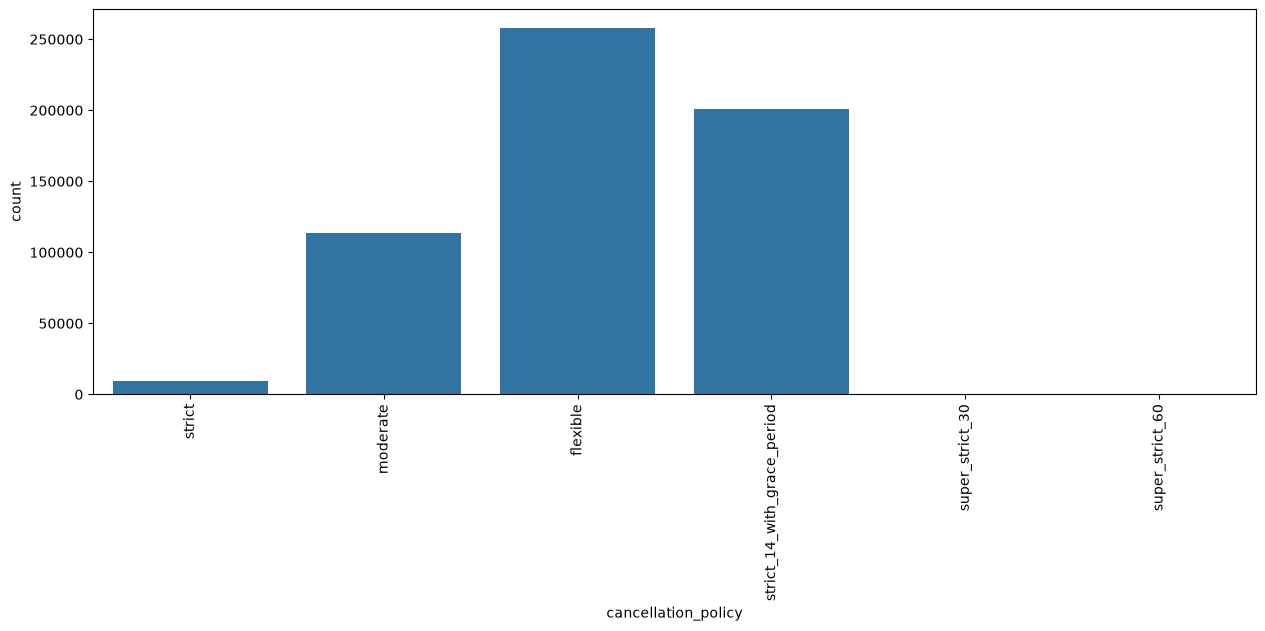

In [40]:
print(base_airbnb['cancellation_policy'].value_counts())
plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='cancellation_policy', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

['strict', 'super_strict_60', 'super_strict_30']
cancellation_policy
flexible                       258096
strict_14_with_grace_period    200743
moderate                       113281
strict                           9863
Name: count, dtype: int64


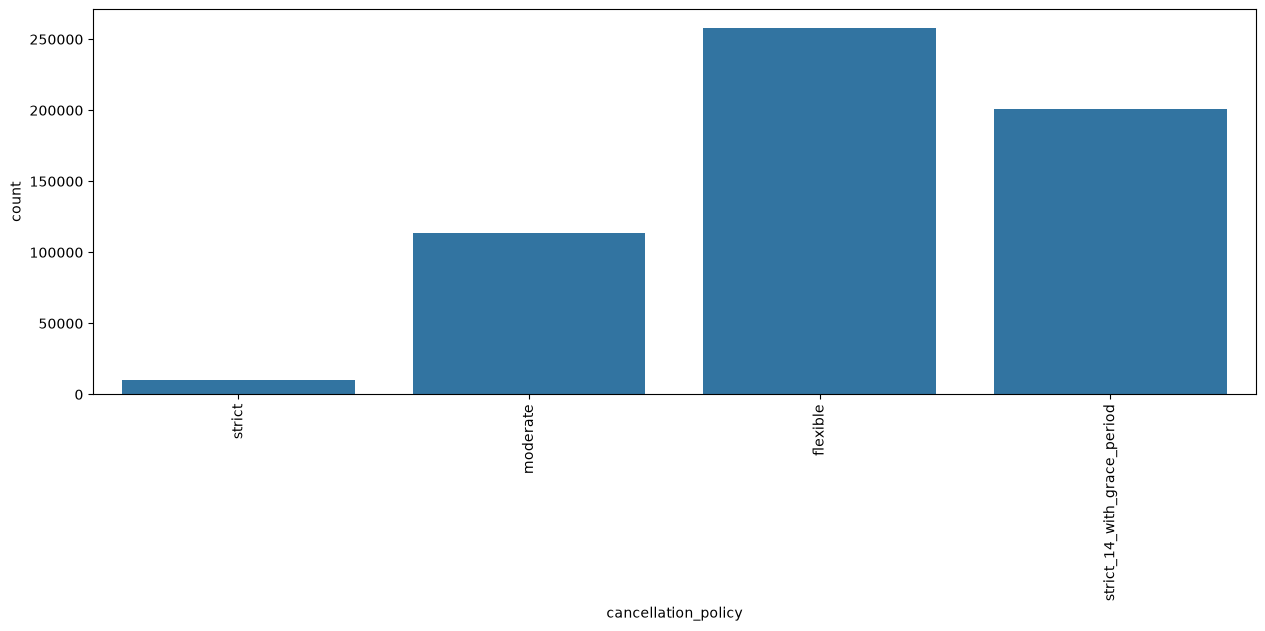

In [41]:
estritos_geral = base_airbnb['cancellation_policy'].value_counts()
colunas_estritas = []

for tipo in estritos_geral.index:
    if estritos_geral[tipo] < 10000:
        colunas_estritas.append(tipo)
print(colunas_estritas)

for tipo in colunas_estritas:
    base_airbnb.loc[base_airbnb['cancellation_policy']==tipo, 'cancellation_policy'] = 'strict'

print(base_airbnb['cancellation_policy'].value_counts())

plt.figure(figsize=(15, 5))
grafico = sns.countplot(x='cancellation_policy', data=base_airbnb)
grafico.tick_params(axis='x', rotation=90)

## Coluna amenities

- Em detrimento da diversidade muito grande de amenities, vamos avaliar essa coluna apenas pela quantidade, sendo esse, o parametro utilizado para o nosso modelo.

In [42]:
base_airbnb['n_amenities'] = base_airbnb['amenities'].str.split(',').apply(len)

In [43]:
base_airbnb = base_airbnb.drop('amenities', axis=1)
base_airbnb.shape

(581983, 20)

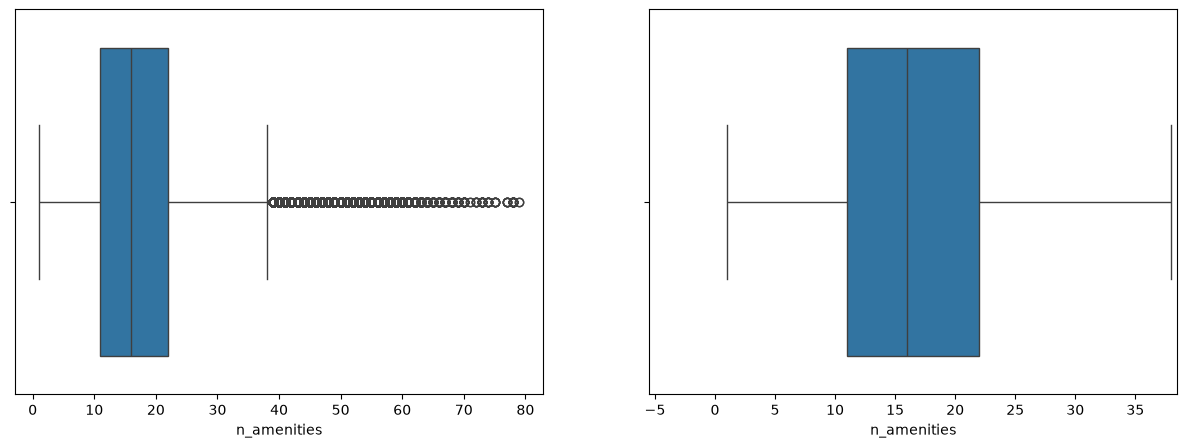

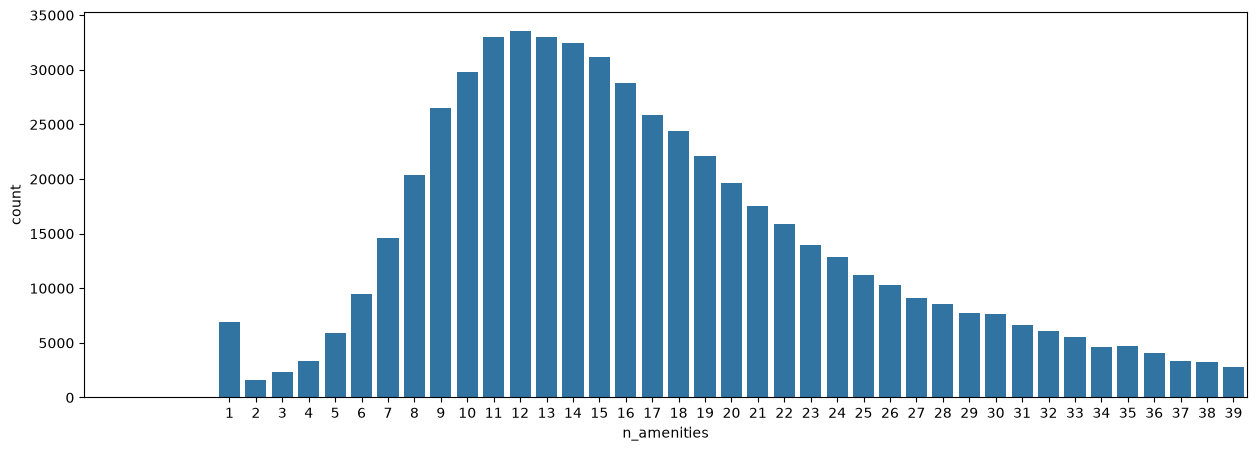

In [44]:
diagrama_caixa(base_airbnb['n_amenities'])
grafico_barra(base_airbnb['n_amenities'])

In [45]:
base_airbnb, linhas_excluidas = excluir_outlier(base_airbnb, 'n_amenities')
print(f'{linhas_excluidas} linhas removidas')

24343 linhas removidas


## Visualização de Mapa

In [46]:
amostra = base_airbnb.sample(n=50000)
centro_mapa = {'lat':amostra.latitude.mean(), 'lon':amostra.longitude.mean()}
mapa = px.density_map(amostra, lat='latitude', lon='longitude', z='price', radius=2.5,
                        center=centro_mapa, zoom=10,
                        map_style='open-street-map')
mapa.show()

## Encoding

- Precisamos ajustar as features para facilitar o trabalho do modelo
- Features de valores True or False, serão substítuidas por 1 ou 0
- Features de Categoria (em que os valores das colunas são textos) vamos utilizar o método de encoding de variáveis dummies

In [47]:
colunas_vf = ['host_is_superhost', 'instant_bookable', 'is_business_travel_ready']
base_airbnb_cod = base_airbnb.copy()

for coluna in colunas_vf:
    base_airbnb_cod.loc[base_airbnb_cod[coluna]=='t',coluna] = '1'
    base_airbnb_cod.loc[base_airbnb_cod[coluna]=='f',coluna] = '0'
    base_airbnb_cod[coluna] = base_airbnb_cod[coluna].astype(int)

In [48]:
colunas_categorias = ['property_type', 'room_type', 'bed_type', 'cancellation_policy']
base_airbnb_cod = pd.get_dummies(base_airbnb_cod, columns=colunas_categorias, dtype=int)
display(base_airbnb_cod.head)

<bound method NDFrame.head of         host_is_superhost  host_listings_count   latitude  longitude  \
1                       1                  2.0 -22.965919 -43.178962   
3                       0                  3.0 -22.977117 -43.190454   
4                       1                  1.0 -22.983024 -43.214270   
5                       1                  1.0 -22.988165 -43.193588   
6                       1                  1.0 -22.981269 -43.190457   
...                   ...                  ...        ...        ...   
902204                  0                  1.0 -22.986030 -43.191660   
902205                  0                  0.0 -23.003180 -43.342840   
902206                  0                  0.0 -22.966640 -43.393450   
902208                  0                  0.0 -23.003400 -43.341820   
902209                  0                  5.0 -23.010560 -43.363350   

        accommodates  bathrooms  bedrooms  beds  price  extra_people  ...  \
1                  5        

## Modelo de Previsão

In [49]:
def avaliar_modelo(nome_modelo, y_teste, previsao):
    r2 = r2_score(y_teste, previsao)
    RSME = np.sqrt(mean_squared_error(y_teste, previsao))
    return f'Modelo {nome_modelo}:\nR²:{r2:.2%}\nRSME:{RSME:.2f}'
#RSME = Erro quadrático médio

- Modelos que serão testados
- RandomForest
- Extra Trees
- LinearRegression

In [50]:
modelo_randomf = RandomForestRegressor()
modelo_linearr = LinearRegression()
modelo_extrat = ExtraTreesRegressor()

modelos = {'RandomForest': modelo_randomf,
           'LinearRegression': modelo_linearr,
           'ExtraTrees': modelo_extrat,
           }
y = base_airbnb_cod['price']
x = base_airbnb_cod.drop('price', axis=1)

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=10)

for nome_modelo, modelo in modelos.items():
    modelo.fit(x_train, y_train)
    previsao = modelo.predict(x_test)
    print(avaliar_modelo(nome_modelo, y_test, previsao))

Modelo RandomForest:
R²:97.24%
RSME:44.04
Modelo LinearRegression:
R²:32.70%
RSME:217.54
Modelo ExtraTrees:
R²:97.51%
RSME:41.86


In [52]:
for nome_modelo, modelo in modelos.items():
    previsao = modelo.predict(x_test)
    print(avaliar_modelo(nome_modelo, y_test, previsao))

Modelo RandomForest:
R²:97.24%
RSME:44.04
Modelo LinearRegression:
R²:32.70%
RSME:217.54
Modelo ExtraTrees:
R²:97.51%
RSME:41.86


- Modelo escolhido: ExtraTreesRegressor
- Através dos resultados podemos observar que o modelo de ExtraTrees, apresentou o melhor resultado de R² e RSME, comparado com os outros. Também podemos citar como outro fator decisivo o tempo de execução do modelo, sendo muito próximo dos outros e com resultados melhores.
- Resultado do melhor modelo:<br>
Modelo ExtraTrees:<br>
R²:97.51%<br>
RSME:41.86

## Ajustes/Melhorias no modelo escolhido

,0
bedrooms,0.116576
latitude,0.104035
longitude,0.101073
n_amenities,0.088914
extra_people,0.085972
accommodates,0.075155
bathrooms,0.068835
minimum_nights,0.065771
room_type_Entire home/apt,0.061443
beds,0.052830


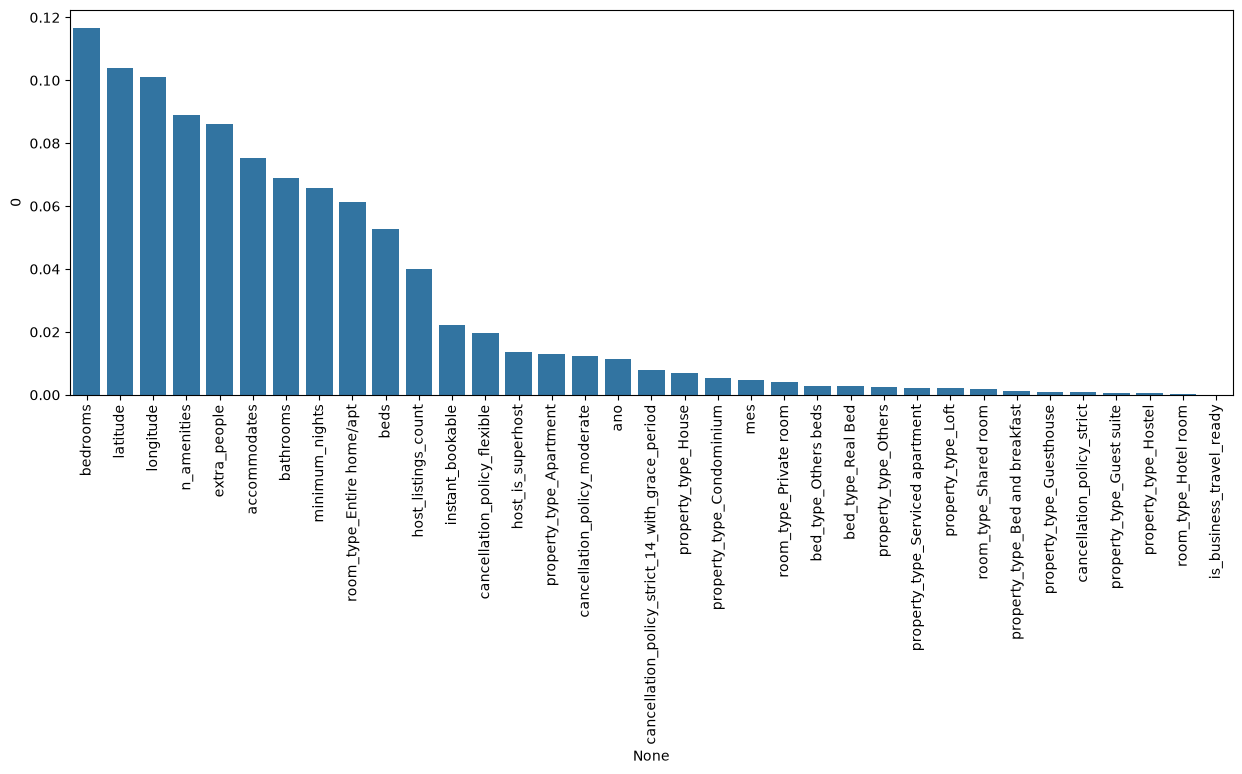

In [53]:
importance_features = pd.DataFrame(modelo_extrat.feature_importances_, x_train.columns)
importance_features = importance_features.sort_values(by=0, ascending=False)
display(importance_features)

plt.figure(figsize=(15, 5))
ax = sns.barplot(x=importance_features.index,y=importance_features[0])
ax.tick_params(axis='x', rotation=90)

In [54]:
base_airbnb_cod = base_airbnb_cod.drop('is_business_travel_ready', axis=1)
x = base_airbnb_cod['price']
y = base_airbnb_cod.drop('price', axis=1)
modelo_extrat.fit(x_train, y_train)
previsao = modelo_extrat.predict(x_test)
print(avaliar_modelo('ExtraTrees', y_test, previsao))

Modelo ExtraTrees:
R²:97.50%
RSME:41.94


In [55]:
base_teste = base_airbnb_cod.copy()
for coluna in base_teste:
    if 'bed_type' in coluna:
        base_teste = base_teste.drop(coluna, axis=1)
print(base_teste.columns)
y = base_teste['price']
x = base_teste.drop('price', axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=10)

modelo_extrat.fit(x_train, y_train)
previsao = modelo_extrat.predict(x_test)
print(avaliar_modelo('ExtraTrees', y_test, previsao))

Index(['host_is_superhost', 'host_listings_count', 'latitude', 'longitude',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'extra_people', 'minimum_nights', 'instant_bookable', 'ano', 'mes',
       'n_amenities', 'property_type_Apartment',
       'property_type_Bed and breakfast', 'property_type_Condominium',
       'property_type_Guest suite', 'property_type_Guesthouse',
       'property_type_Hostel', 'property_type_House', 'property_type_Loft',
       'property_type_Others', 'property_type_Serviced apartment',
       'room_type_Entire home/apt', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'cancellation_policy_flexible', 'cancellation_policy_moderate',
       'cancellation_policy_strict',
       'cancellation_policy_strict_14_with_grace_period'],
      dtype='str')
Modelo ExtraTrees:
R²:97.49%
RSME:42.01


In [56]:
print(previsao)

[101.   998.62 249.21 ... 125.01 272.72 119.83]


## Deploy

In [57]:
x['price'] = y
x.to_csv('dados.csv')

In [58]:
import joblib
joblib.dump(modelo_extrat, 'modelo.joblib')
joblib.dump(list(x_train.columns), 'colunas_modelo.joblib')

['colunas_modelo.joblib']